In [1]:
# ---------------------------------------------------------------
# Script to Generate Scatter Plot of Observed Time Series by Age
# Comparison between my estimations and DHS Data
# Created by Felipe Sanchez
# Date: May 23, 2024
# ---------------------------------------------------------------

# Import necessary packages
using Turing
using MCMCChains
using Distributions
using RData
using CSV
using XLSX
using DataFrames
using LinearAlgebra
using StatsFuns
using Random
using Serialization
using CairoMakie
using AlgebraOfGraphics
using Plots
using StatsPlots
using Gadfly
using KernelDensity
using Colors
using CategoricalArrays

# Ensure all required modules are imported from each package
using AlgebraOfGraphics: density
using DataFrames: stack
using CairoMakie: violin

# Define directory path for data input and output
dir = "/Users/felipesanchez/Documents/UoM/PhD/Phd Third Year/Chapter Fertility/ModellingF/Output/"

# ---------------------------------------------------------------
# Note:
# - This script uses various packages for statistical analysis,
#   data manipulation, and visualization.
# - Ensure all listed packages are installed in your Julia environment.
# - AMBA Average Mortality by Age and after one by year after the age-group 25-29 and so on
# ---------------------------------------------------------------

# Add further code for your data analysis and visualization below this line


"/Users/felipesanchez/Documents/UoM/PhD/Phd Third Year/Chapter Fertility/ModellingF/Output/"

In [2]:
#Fertility
lmuf = deserialize("/Users/felipesanchez/Documents/UoM/PhD/Phd Third Year/Chapter Fertility/ModellingF/Data_Created/lmu.jls")
#Mortality
lmum = deserialize("/Users/felipesanchez/Documents/UoM/PhD/Phd Third Year/Chapter Mortality/ModellingM/Data_Created/lmu.jls")
#Fertility DHS


8-element Vector{DataFrame}:
 11×21 DataFrame
 Row │ 1         2         3         4         5         6         7         8 ⋯
     │ Float64   Float64   Float64   Float64   Float64   Float64   Float64   F ⋯
─────┼──────────────────────────────────────────────────────────────────────────
   1 │ -7.37662  -6.84376  -6.5514   -6.24822  -5.85257  -5.85072  -5.69847  - ⋯
   2 │ -7.5609   -6.90446  -6.50059  -6.14931  -5.90058  -5.88722  -5.64622  -
   3 │ -7.51388  -6.93676  -6.38828  -6.13962  -5.83885  -5.83885  -5.9993   -
   4 │ -7.21144  -6.93133  -6.64866  -6.34731  -6.18493  -6.0542   -5.92655  -
   5 │ -6.94483  -6.60866  -6.25896  -6.12316  -5.90953  -5.72309  -5.66962  - ⋯
   6 │ -6.60457  -6.31702  -6.00347  -5.68721  -5.60749  -5.39543  -5.2462   -
   7 │ -6.2023   -5.93112  -5.84086  -5.6255   -5.49465  -5.34135  -5.30898  -
   8 │ -5.59902  -5.316    -5.29612  -5.08486  -5.01498  -4.86473  -4.83084  -
   9 │ -5.17905  -4.92339  -4.74363  -4.55371  -4.43509  -4.38044  -4.39541

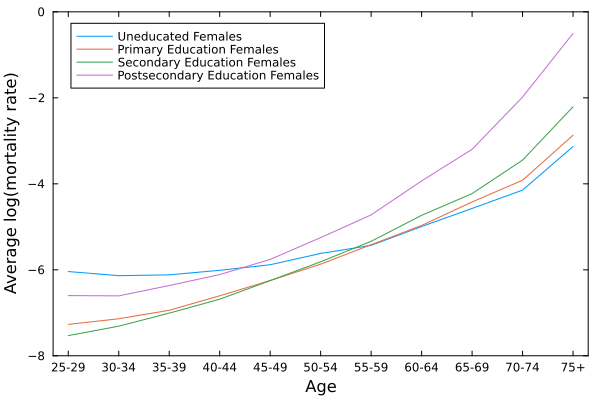

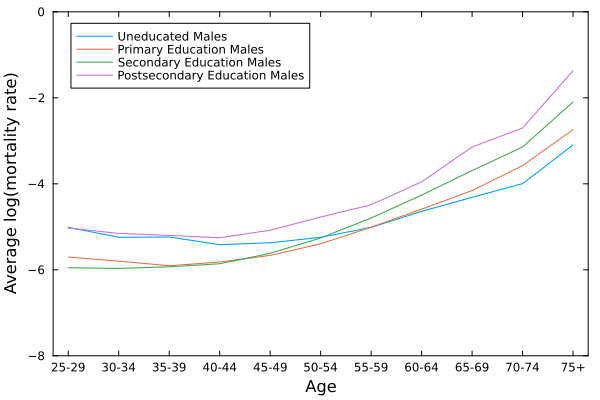

"/Users/felipesanchez/Documents/UoM/PhD/Phd Third Year/Chapter Mortality/ModellingM/Output/amba/males_average_lmum.png"

In [5]:
# Define the ages and years
ages = ["25-29", "30-34", "35-39", "40-44", "45-49", "50-54", "55-59", "60-64", "65-69", "70-74", "75+"]
years = 1998:2018

# Define the labels for each group
female_labels = ["Uneducated Females", "Primary Education Females", "Secondary Education Females", "Postsecondary Education Females"]
male_labels = ["Uneducated Males", "Primary Education Males", "Secondary Education Males", "Postsecondary Education Males"]

# Function to plot average log mortality rate for multiple groups
function plot_average_log_mortality_groups(lmum_matrices, labels, filename)
    p = Plots.plot()
    for (lmum_matrix, label) in zip(lmum_matrices, labels)
        # Create the DataFrame from the matrix with automatically generated column names
        lmum_df = DataFrame(lmum_matrix, :auto)

        # Add the 'Age' column after transposing the matrix
        lmum_df = hcat(DataFrame(Age=ages), lmum_df)

        # Rename the columns to have 'Age' and years as column names
        rename!(lmum_df, Symbol.(["Age"; string.(years)]))

        # Convert to long format for easier manipulation
        lmum_long = stack(lmum_df, Not(:Age), variable_name=:Year, value_name=:log_mortality_rate)

        # Convert 'Year' to integer and 'Age' to categorical
        lmum_long.Year = parse.(Int, lmum_long.Year)
        lmum_long.Age = categorical(lmum_long.Age)

        # Calculate the average log mortality rate for each age group
        average_log_mortality_rate = combine(groupby(lmum_long, :Age), :log_mortality_rate => mean => :average_log_mortality_rate)

        # Convert 'Age' to categorical for plotting
        average_log_mortality_rate.Age = categorical(average_log_mortality_rate.Age)

        # Create the plot for this group
        Plots.plot!(p, average_log_mortality_rate.Age, average_log_mortality_rate.average_log_mortality_rate, 
                    linewidth=1.05, 
                    xlabel="Age", ylabel="Average log(mortality rate)", 
                    label=label, 
                    ylim=(-8, 0))
    end

    # Customize the theme
    Plots.plot!(p, xtickfont=font(8, "sans-serif", rotation=90), yticks=:auto, grid=false, framestyle=:box)

    # Display the plot
    display(p)

    # Save the plot to a file
    savefig(p, filename)
end

# Plot for females
plot_average_log_mortality_groups([Matrix(lmum[1]), Matrix(lmum[2]), Matrix(lmum[3]), Matrix(lmum[4])], 
                                  female_labels, 
                                  "/Users/felipesanchez/Documents/UoM/PhD/Phd Third Year/Chapter Mortality/ModellingM/Output/amba/females_average_lmum.png")

# Plot for males
plot_average_log_mortality_groups([Matrix(lmum[5]), Matrix(lmum[6]), Matrix(lmum[7]), Matrix(lmum[8])], 
                                  male_labels, 
                                  "/Users/felipesanchez/Documents/UoM/PhD/Phd Third Year/Chapter Mortality/ModellingM/Output/amba/males_average_lmum.png")

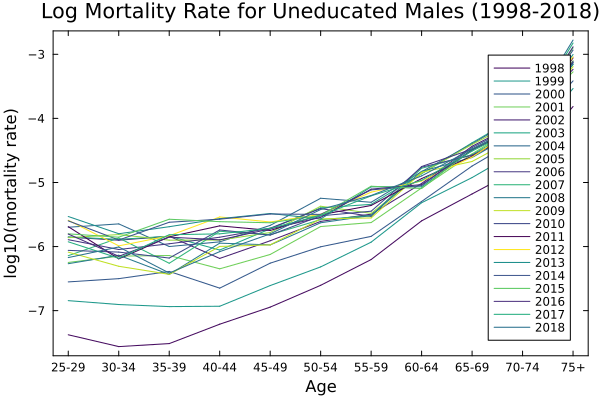

"/Users/felipesanchez/Documents/UoM/PhD/Phd Third Year/Chapter Mortality/ModellingM/Output/amba/lmum1.png"

In [4]:
using DataFrames
using Plots
using Colors
using CategoricalArrays

# Define the ages and years
ages = ["25-29", "30-34", "35-39", "40-44", "45-49", "50-54", "55-59", "60-64", "65-69", "70-74", "75+"]
years = 1998:2018

# Assuming lmum[1] is your DataFrame containing the log mortality rates as a 11×21 DataFrame
# Transpose the matrix and create a new DataFrame
lmum1_matrix = Matrix(lmum[1])

# Create the DataFrame from the matrix with automatically generated column names
lmum1_df = DataFrame(lmum1_matrix, :auto)

# Add the 'Age' column after transposing the matrix
lmum1_df = hcat(DataFrame(Age=ages), lmum1_df)

# Rename the columns to have 'Age' and years as column names
rename!(lmum1_df, Symbol.(["Age"; string.(years)]))

# Convert to long format for easier plotting
lmum1_long = stack(lmum1_df, Not(:Age), variable_name=:Year, value_name=:log_mortality_rate)

# Convert 'Year' to integer and 'Age' to categorical
lmum1_long.Year = parse.(Int, lmum1_long.Year)
lmum1_long.Age = categorical(lmum1_long.Age)

# Define the viridis color palette
viridis_colors = cgrad(:viridis, rev=false)

# Create the plot
p = Plots.plot(lmum1_long.Age, lmum1_long.log_mortality_rate, group=lmum1_long.Year, color=lmum1_long.Year, 
         linewidth=1.05, palette=viridis_colors, 
         xlabel="Age", ylabel="log10(mortality rate)", 
         title="Log Mortality Rate for Uneducated Males (1998-2018)",
         legend=:right)

# Customize the theme
Plots.plot!(p, xtickfont=font(8, "sans-serif", rotation=90), yticks=:auto, grid=false, framestyle=:box)

# Display the plot
display(p)

# Save the plot to a file
savefig(p, "/Users/felipesanchez/Documents/UoM/PhD/Phd Third Year/Chapter Mortality/ModellingM/Output/amba/lmum1.png")
